In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ortho_group


In [18]:
S=6

t=100
dt=0.01

flag=0

mu_l=0.5
sigma_l=0.05

sigma_n=0.02

x_0=np.random.uniform(0,1,S)

In [19]:
lista=np.random.uniform(0,1,S)
L = np.diag(lista)
U=ortho_group.rvs(dim=S)
U_T=np.transpose(U)

W=U@L@U_T

C=np.random.rand()

while True:
    if(flag==0):
        Tau=np.random.lognormal(mu_l,sigma_l,S)
        A=np.diag([-1]*S)/10
    if(flag==1):
        Tau=np.random.lognormal(mu_l,sigma_l,S)
        lista=-1/Tau
        A=np.diag(lista)


    for i in range(S):
        for j in range(S):
            if i!=j:
                if np.random.rand() < C:
                    A[i][j]=np.random.normal(0, sigma_n)
                        
    eigval=np.linalg.eigvals(A)
    stable=np.all(np.real(eigval)<0)
    if stable:
        break


print(stable)
print(C)
print(A)  
print(W)


True
0.9604895252756587
[[-0.1        -0.03527014 -0.03148019 -0.01466452  0.01694414 -0.0087322 ]
 [ 0.01261466 -0.1         0.01803528  0.00315532  0.01982779 -0.00139393]
 [ 0.03073591  0.0347065  -0.1        -0.03840775 -0.02294024  0.03909024]
 [-0.00522326  0.02610826 -0.01641678 -0.1         0.01518609 -0.01885468]
 [ 0.0234053  -0.0211361   0.02215598  0.04613798 -0.1         0.00519069]
 [ 0.0073078  -0.00025864 -0.01292587  0.01314304 -0.01881954 -0.1       ]]
[[ 0.18684817  0.07610344 -0.00445222  0.08771864  0.00362367  0.07025758]
 [ 0.07610344  0.28535932  0.1141291   0.16181652  0.06967403 -0.11317972]
 [-0.00445222  0.1141291   0.36163917 -0.09402164  0.00904452 -0.03509584]
 [ 0.08771864  0.16181652 -0.09402164  0.36954906  0.00255242  0.05739364]
 [ 0.00362367  0.06967403  0.00904452  0.00255242  0.05466951 -0.04092715]
 [ 0.07025758 -0.11317972 -0.03509584  0.05739364 -0.04092715  0.36809248]]


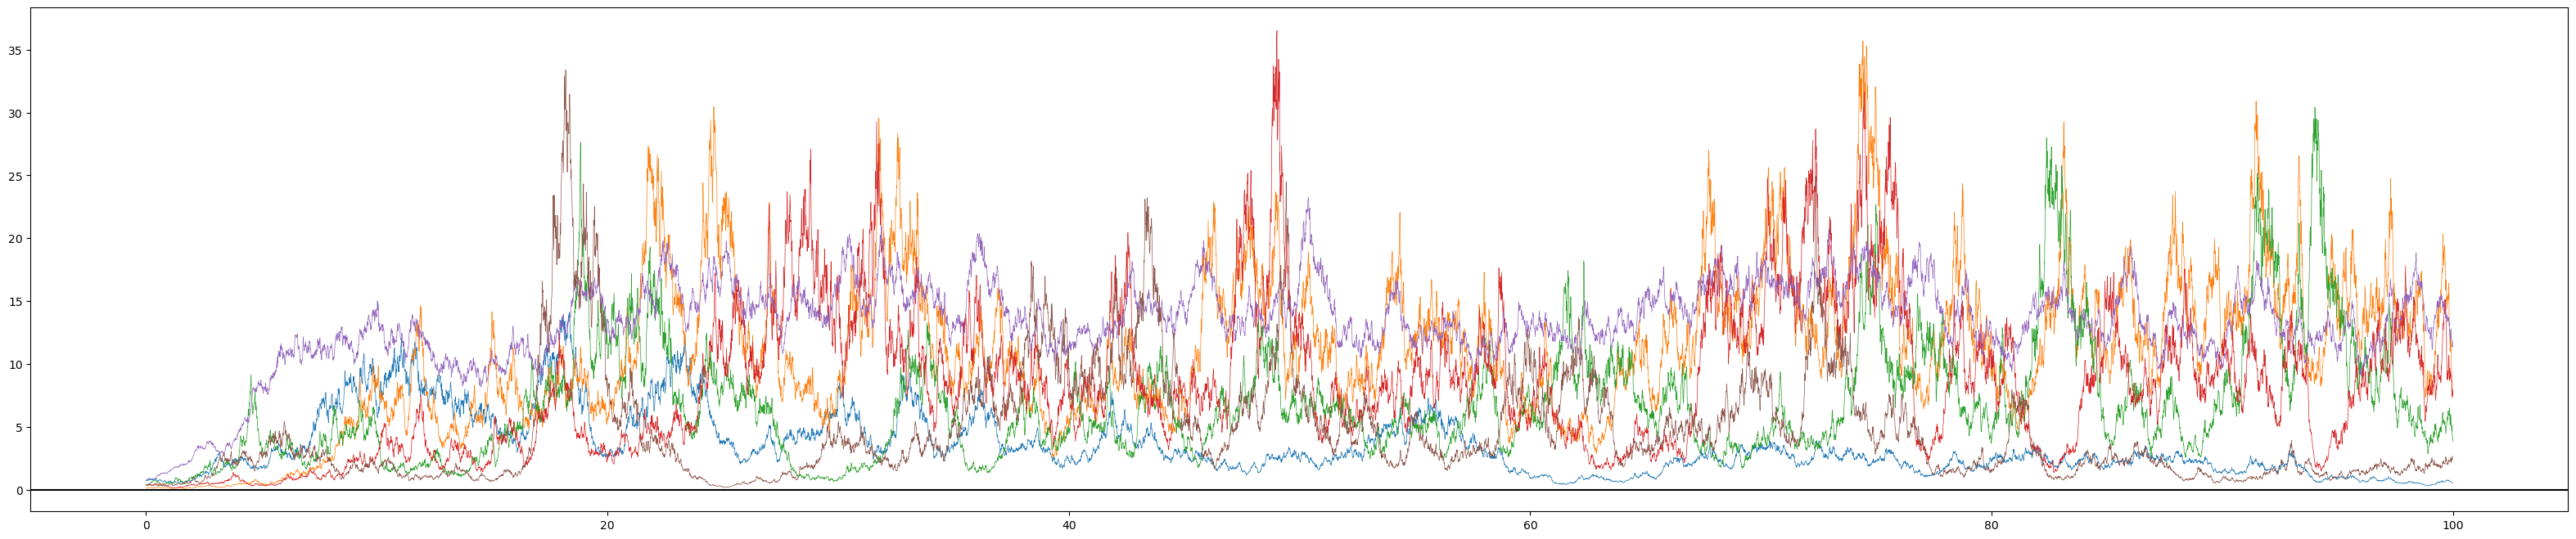

In [20]:
tl=[]
xl=[]

with open("x_especies(t).txt","w") as f:
    f.write("Time\t")
    for k in range (S):
        f.write(f"Especie_{k+1}\t" )
    f.write("\n")
    f.close
x=x_0

P=int(t/dt)

for h in range(P):
    dW = np.random.multivariate_normal(mean=np.zeros(S), cov=W)*np.sqrt(dt)
    t=h*dt
    tl.append(t)
    xl.append(x)
    k=0
    with open("x_especies(t).txt","a") as f:
        f.write(f"{t:.2f}\t")
        for k in range(S):
            f.write(f"{x[k]:.4f}\t")
        f.write("\n")
        f.close
    
    x_new=x + dt*(x/Tau)*(1+A@x) + dW*x
    x=x_new
    
    for v in range(S-1):
        if (x[v]<0):
            print("MAL!")
    


        
        

plt.figure(figsize=(40,8))
plt.plot(tl, xl, lw=0.5)
plt.axhline(0, color='black')
plt.show()



    
    
    
